## 4. Create a non-linearly separable 2D dataset (e.g., concentric circles or "moons").
### a) Attempt to classify it using a Linear SVM.
### b) Implement a Gaussian RBF Kernel to project the data into a higher dimension.
### c) Visualize the decision boundary in the original 2D space.

Linear SVM Accuracy: 0.85
RBF SVM Accuracy: 0.96


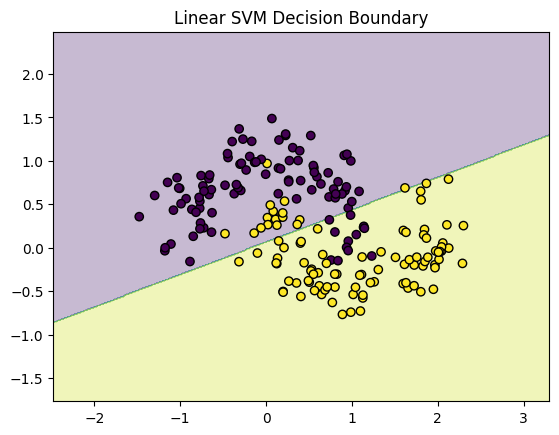

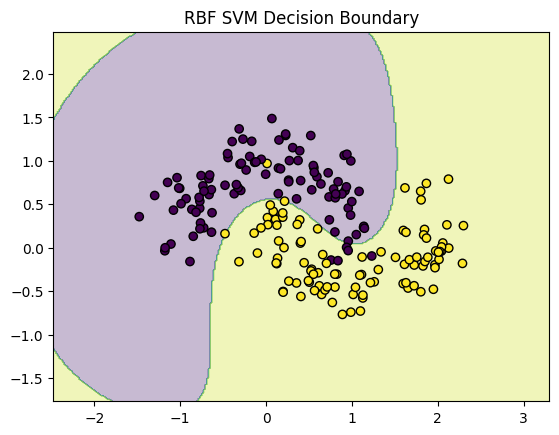

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Generate Nonlinear Dataset

X, y = make_moons(n_samples=200, noise=0.2, random_state=42)

# Train Linear SVM
svm_linear = SVC(kernel='linear')
svm_linear.fit(X, y)

pred_linear = svm_linear.predict(X)
acc_linear = accuracy_score(y, pred_linear)

print("Linear SVM Accuracy:", acc_linear)


# Train RBF SVM
svm_rbf = SVC(kernel='rbf', gamma='scale')
svm_rbf.fit(X, y)

pred_rbf = svm_rbf.predict(X)
acc_rbf = accuracy_score(y, pred_rbf)

print("RBF SVM Accuracy:", acc_rbf)


# Function to Plot Decision Boundary
def plot_decision_boundary(model, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
    plt.title(title)
    plt.show()

# Plot Both Models
plot_decision_boundary(svm_linear, "Linear SVM Decision Boundary")
plot_decision_boundary(svm_rbf, "RBF SVM Decision Boundary")


Linear SVM:

* Straight line boundary

* Many misclassified points

* Lower accuracy

RBF SVM:

* Curved boundary

* Separates classes correctly

* Higher accuracy

The linear SVM fails to separate the make_moons dataset because the data is not linearly separable. The RBF kernel maps the data into a higher-dimensional feature space using a Gaussian similarity function, enabling nonlinear separation. This demonstrates the power of kernel methods in handling complex data structures.